# Term
* counterfactual

    > relating to or expressing what has not happened or is not the case

* hallucination

    > A hallucination is a perception in the absence of an external context stimulus that has the compelling sense of reality

# SHAP
> SHAP analysis complements global sensitivity analysis by characterising the contribution and direction of predictive features in the PIML models, including measured and time-varying variables. Sobol analysis is used to quantify the contribution of predefined uncertain inputs to output variance. Applying SHAP consistently across the PIML models further enables their learned feature–response relationships to be compared in terms of physical plausibility and consistency.

In [1]:
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Base dataset 
rng = np.random.default_rng(42)
n_samples = 1000

# Key features
X = pd.DataFrame({
    "Outdoor temperature": rng.normal(8, 5, n_samples),
    "Heating setpoint": rng.normal(21, 1, n_samples),
    "Occupancy": rng.uniform(0, 1, n_samples),
    "Infiltration rate": rng.uniform(0.1, 1.0, n_samples),
    "U-value": rng.uniform(0.2, 1.5, n_samples),
})

# Synthetic heating-energy response
y = (
    200
    - 12 * X["Outdoor temperature"]
    + 18 * X["Heating setpoint"]
    + 70 * X["Infiltration rate"]
    + 50 * X["U-value"]
    + 20 * X["Occupancy"]
    + rng.normal(0, 10, n_samples)
)

c:\Users\s2589602\.conda\envs\eplus_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Model training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

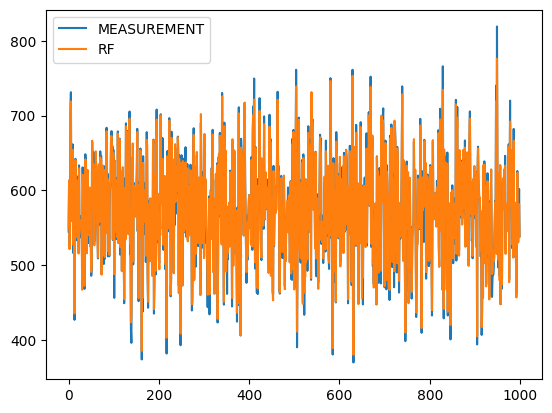

In [ ]:
import matplotlib.pyplot as plt
y_pred = model.predict(X)
plt.plot(y, label="MEASUREMENT")
plt.plot(y_pred, label="RF")
plt.legend()
plt.show()

# Visualisation
* A SHAP beeswarm plot summarises how each feature influences model predictions across all samples.

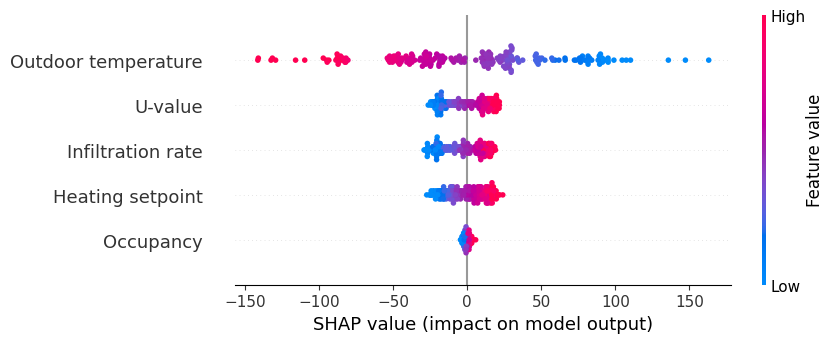

In [ ]:


explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(
    shap_values,
    max_display=10,
)

* A SHAP dependence plot shows how one feature’s actual value relates to its contribution to the model prediction.

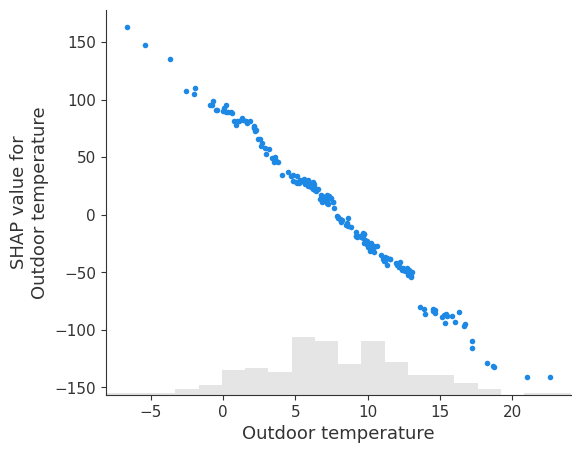

In [ ]:
shap.plots.scatter(
    shap_values[:, "Outdoor temperature"]
)